In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Set dataset paths
train_path = "/content/drive/MyDrive/Root folder/Semester 6/Artificial Intelligence/Week 4/DevanagariHandwrittenDigitDataset/Train"
test_path = "/content/drive/MyDrive/Root folder/Semester 6/Artificial Intelligence/Week 4/DevanagariHandwrittenDigitDataset/Test"

IMG_SIZE = 32

In [8]:
# Load Devanagari images using PIL
def load_devanagari_images(folder_path, img_size=32):
    images = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                img_path = os.path.join(root, file)

                img = Image.open(img_path).convert("L")
                img = img.resize((img_size, img_size))

                img_array = np.array(img).astype("float32") / 255.0
                images.append(img_array)

    images = np.array(images)
    images = images.reshape(-1, img_size, img_size, 1)

    return images

**Loading Train and Test Images**

In [9]:
# Load train and test images
X_train = load_devanagari_images(train_path, IMG_SIZE)
X_test = load_devanagari_images(test_path, IMG_SIZE)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Train pixel range:", X_train.min(), "to", X_train.max())
print("Test pixel range:", X_test.min(), "to", X_test.max())

Training data shape: (17000, 32, 32, 1)
Testing data shape: (3000, 32, 32, 1)
Train pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


**Adding Gaussian Noise**

In [20]:
# Add Gaussian noise
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

# Keep pixel values between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

SyntaxError: invalid syntax (3454005158.py, line 10)

**Visualizing the Images after Implementation of Gaussian Noise**

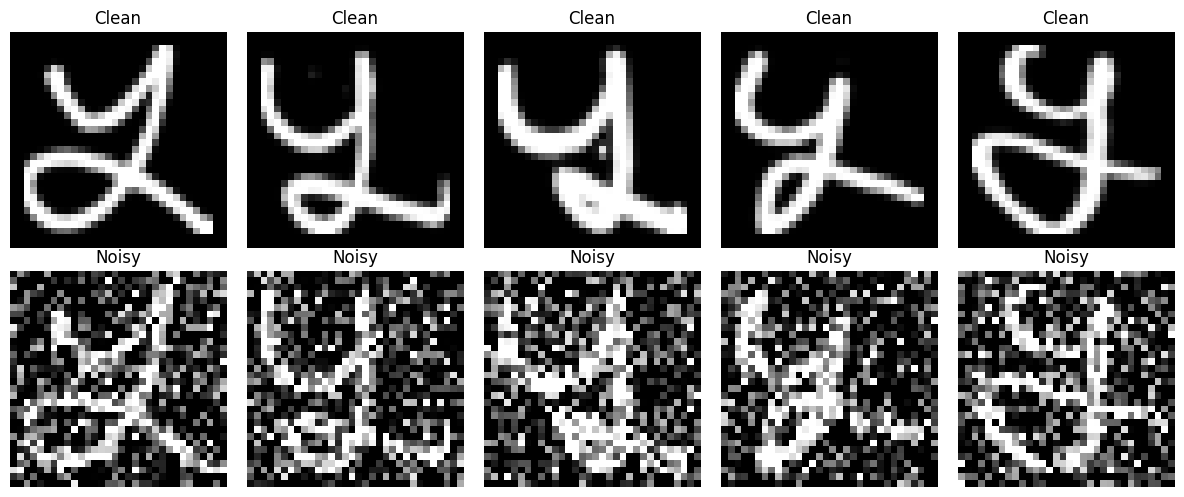

In [11]:
# Visualize clean and noisy images
n = 5
plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Building Encoder**

In [13]:
# Build encoder
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)

    return input_img, encoded

**Building Decoder**

In [12]:
# Build decoder
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)

    return decoded

**Building AutoEncoder**

In [14]:
# Build full autoencoder
def build_autoencoder():
    input_img, encoded_output = build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(
        inputs=input_img,
        outputs=decoded_output,
        name="devanagari_denoising_autoencoder"
    )

    autoencoder.compile(
        optimizer=Adam(),
        loss="binary_crossentropy"
    )

    return autoencoder

In [15]:
# Create and view model
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "devanagari_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**Training the AutoEncoder**

In [16]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 68s 497ms/step - loss: 0.2846 - val_loss: 0.1826
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 77s 464ms/step - loss: 0.1760 - val_loss: 0.1684
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 90s 521ms/step - loss: 0.1670 - val_loss: 0.1630
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 77s 484ms/step - loss: 0.1626 - val_loss: 0.1596
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 81s 474ms/step - loss: 0.1592 - val_loss: 0.1572
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 82s 477ms/step - loss: 0.1566 - val_loss: 0.1548
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 62s 468ms/step - loss: 0.1543 - val_loss: 0.1529
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 473ms/step - loss: 0.1528 - val_loss: 0.1514
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 475ms/step - loss: 0.1512 - val_loss: 0.1509
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 471ms/step - loss: 0.1503 - val_loss: 0.1493


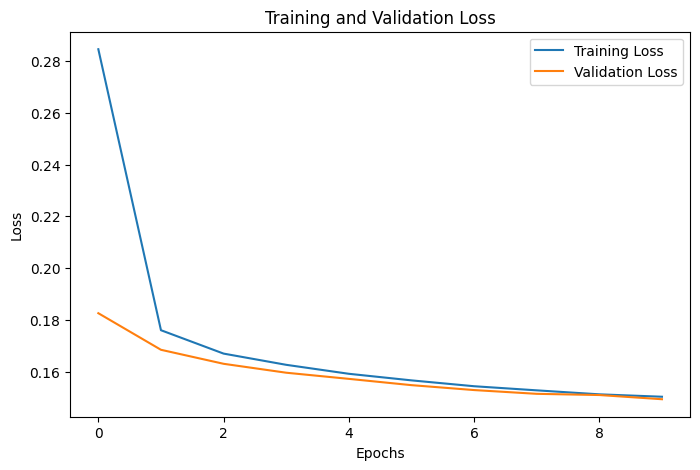

In [17]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [18]:
# Predict denoised images
denoised_images = autoencoder.predict(X_test_noisy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


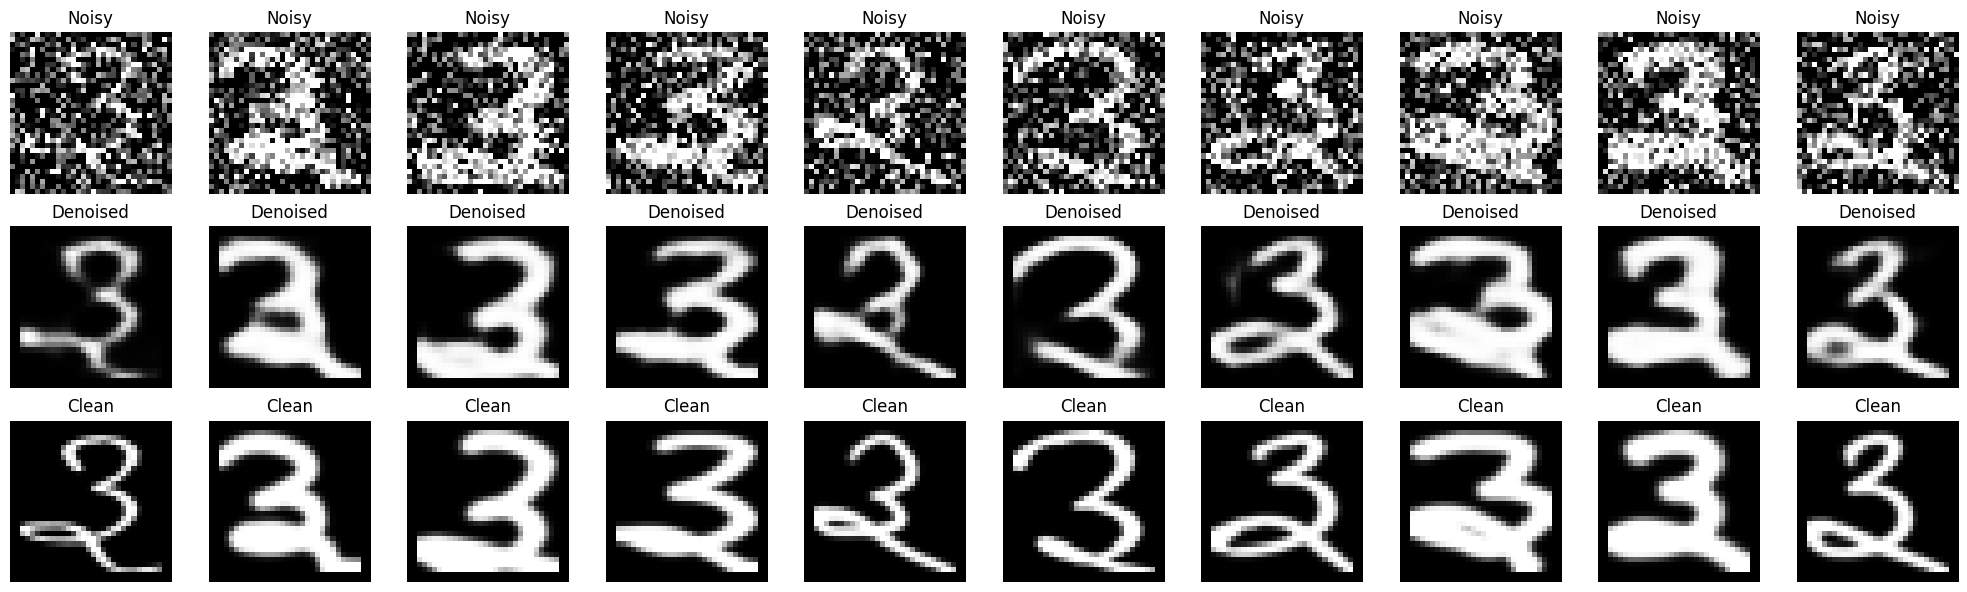

In [19]:
# Visualize noisy, denoised, and clean images
def plot_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_results(X_test_noisy, denoised_images, X_test, n=10)